# DefectVision — 04 Efficient CPU Baseline

This notebook establishes a **fast, legitimate segmentation baseline on CPU**.

We are deliberately separating two things:

1. **Project quality:** full dataset, full 256×256 resolution, proper train/validation/test split, pixel-level masks and rigorous metrics.
2. **Compute:** the baseline architecture is lightweight so that CPU training is practical.

This is NOT the final model. It is a benchmark that the later high-capacity model must beat.

No torchvision, CUDA, Colab or Google Drive is required.


## 1. Imports and configuration


In [1]:
from pathlib import Path
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "MVTecAD-SEG"

IMG_ROOT = DATA_ROOT / "imgs"
ANN_ROOT = DATA_ROOT / "annotations"

CHECKPOINT_DIR = PROJECT_ROOT / "models" / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 1e-3

DEVICE = torch.device("cpu")

print("Using:", DEVICE)
print("Images:", IMAGE_SIZE, "x", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)


Using: cpu
Images: 256 x 256
Batch size: 4
Epochs: 10


## 2. Dataset


In [2]:
class DefectDataset(Dataset):
    def __init__(self, split, augment=False):
        self.split = split
        self.augment = augment

        self.img_dir = IMG_ROOT / split
        self.mask_dir = ANN_ROOT / split

        self.image_paths = sorted(self.img_dir.glob("*.png"))

        if not self.image_paths:
            raise RuntimeError(f"No PNG images found in {self.img_dir}")

        missing = [
            p.name for p in self.image_paths
            if not (self.mask_dir / p.name).exists()
        ]

        if missing:
            raise RuntimeError(
                f"{split}: missing masks. Examples: {missing[:5]}"
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.name

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if image.size != (IMAGE_SIZE, IMAGE_SIZE):
            image = image.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.BILINEAR
            )

        if mask.size != (IMAGE_SIZE, IMAGE_SIZE):
            mask = mask.resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                Image.Resampling.NEAREST
            )

        if self.augment:
            if random.random() < 0.5:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

            if random.random() < 0.5:
                image = image.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

        image_np = np.asarray(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(
            image_np
        ).permute(2, 0, 1).contiguous()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        image_tensor = (image_tensor - mean) / std

        mask_np = np.asarray(mask, dtype=np.uint8)
        mask_tensor = torch.from_numpy(
            (mask_np > 0).astype(np.float32)
        ).unsqueeze(0)

        return image_tensor, mask_tensor, image_path.stem


## 3. DataLoaders


In [3]:
train_dataset = DefectDataset("train", augment=True)
val_dataset = DefectDataset("val", augment=False)
test_dataset = DefectDataset("test", augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 880
Validation: 125
Test: 253


## 4. Efficient segmentation network

Instead of a large U-Net, this baseline uses a compact encoder-decoder with depthwise-separable convolutions.

A depthwise-separable convolution factorizes a normal convolution into:
- depthwise spatial filtering
- pointwise channel mixing

This greatly reduces computation while retaining spatial feature extraction.

The architecture is still a genuine dense pixel-to-pixel segmentation model.


In [4]:
class DSConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class EfficientSegNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DSConv(3, 16, stride=2)      # 256 -> 128
        self.enc2 = DSConv(16, 32, stride=2)     # 128 -> 64
        self.enc3 = DSConv(32, 64, stride=2)     # 64 -> 32
        self.enc4 = DSConv(64, 96, stride=2)     # 32 -> 16

        self.bottleneck = DSConv(96, 128)

        # Decoder
        # 128 -> 32, then concatenate with e3 (64)
        self.dec4 = DSConv(128 + 64, 64)

        # 64 -> 64, then concatenate with e2 (32)
        self.dec3 = DSConv(64 + 32, 32)

        # 32 -> 128, then concatenate with e1 (16)
        self.dec2 = DSConv(32 + 16, 16)

        # 16 -> 256, then concatenate with original input (3)
        self.dec1 = DSConv(16 + 3, 8)

        self.out = nn.Conv2d(8, 1, kernel_size=1)

    def up(self, x):
        return nn.functional.interpolate(
            x,
            scale_factor=2,
            mode="bilinear",
            align_corners=False
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        b = self.bottleneck(e4)

        d4 = self.up(b)
        d4 = torch.cat([d4, e3], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up(d4)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up(d3)
        d2 = torch.cat([d2, e1], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up(d2)
        d1 = torch.cat([d1, x], dim=1)
        d1 = self.dec1(d1)

        # Final 256x256 prediction
        return self.out(d1)


model = EfficientSegNet().to(DEVICE)

params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {params:,}")

Trainable parameters: 44,467


## 5. Forward-pass sanity check


In [5]:
images, masks, ids = next(iter(train_loader))

with torch.no_grad():
    logits = model(images)

print("Input :", tuple(images.shape))
print("Output:", tuple(logits.shape))

assert logits.shape == (
    images.shape[0],
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
)


Input : (4, 3, 256, 256)
Output: (4, 1, 256, 256)


## 6. Loss


In [6]:
# Calculate positive-pixel weight from the training masks

total_pixels = 0
positive_pixels = 0

for _, masks, _ in train_loader:
    positive_pixels += masks.sum().item()
    total_pixels += masks.numel()

negative_pixels = total_pixels - positive_pixels

pos_weight_value = negative_pixels / max(positive_pixels, 1)

# Avoid an excessively large weight
pos_weight_value = min(pos_weight_value, 20.0)

print("Total pixels:", total_pixels)
print("Defect pixels:", int(positive_pixels))
print("Defect fraction:", positive_pixels / total_pixels)
print("Positive class weight:", pos_weight_value)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
        )

        return 1 - dice.mean()


dice = DiceLoss()

bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value)
)


def loss_fn(logits, targets):
    return (
        0.5 * bce(logits, targets)
        + 0.5 * dice(logits, targets)
    )


Total pixels: 57671680
Defect pixels: 2469565
Defect fraction: 0.042821103876287285
Positive class weight: 20.0


In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

## 7. Metrics


In [8]:
@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    pred_area = preds.sum(dim=1)
    true_area = targets.sum(dim=1)

    union = pred_area + true_area - intersection

    dice = (2 * intersection + eps) / (
        pred_area + true_area + eps
    )

    iou = (intersection + eps) / (union + eps)

    tp = intersection
    fp = ((preds == 1) & (targets == 0)).sum(dim=1).float()
    fn = ((preds == 0) & (targets == 1)).sum(dim=1).float()

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    return {
        "dice": dice.mean().item(),
        "iou": iou.mean().item(),
        "precision": precision.mean().item(),
        "recall": recall.mean().item()
    }


## 8. Train / validation functions


In [9]:
def train_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_items = 0

    for images, masks, _ in loader:
        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = loss_fn(logits, masks)

        loss.backward()
        optimizer.step()

        n = images.size(0)
        total_loss += loss.item() * n
        total_items += n

    return total_loss / total_items


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    totals = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0
    }

    for images, masks, _ in loader:
        logits = model(images)
        loss = loss_fn(logits, masks)

        n = images.size(0)
        total_loss += loss.item() * n
        total_items += n

        m = compute_metrics(logits, masks)

        for key in totals:
            totals[key] += m[key] * n

    result = {"loss": total_loss / total_items}

    for key in totals:
        result[key] = totals[key] / total_items

    return result


## 9. Train


In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

history = []
best_dice = -1.0
best_state = None
best_epoch = 0

start = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer
    )

    val = evaluate(
        model,
        val_loader
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val["loss"],
        "val_dice": val["dice"],
        "val_iou": val["iou"],
        "val_precision": val["precision"],
        "val_recall": val["recall"]
    })

    if val["dice"] > best_dice:
        best_dice = val["dice"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": best_state,
                "val_dice": best_dice,
                "val_iou": val["iou"]
            },
            CHECKPOINT_DIR / "efficient_baseline_best.pth"
        )

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train {train_loss:.4f} | "
        f"val {val['loss']:.4f} | "
        f"Dice {val['dice']:.4f} | "
        f"IoU {val['iou']:.4f} | "
        f"{time.time() - epoch_start:.1f}s"
    )

print()
print("Best validation Dice:", round(best_dice, 4))
print("Best epoch:", best_epoch)
print("Total time (min):", round((time.time() - start) / 60, 2))


Epoch 1/10 | train 1.0516 | val 1.0195 | Dice 0.1479 | IoU 0.0950 | 163.7s
Epoch 2/10 | train 0.9700 | val 0.9646 | Dice 0.1567 | IoU 0.0988 | 178.3s
Epoch 3/10 | train 0.9247 | val 0.9459 | Dice 0.1602 | IoU 0.1021 | 193.9s
Epoch 4/10 | train 0.9089 | val 0.9340 | Dice 0.1786 | IoU 0.1175 | 155.8s
Epoch 5/10 | train 0.8872 | val 0.8932 | Dice 0.2054 | IoU 0.1399 | 176.4s
Epoch 6/10 | train 0.8722 | val 0.9155 | Dice 0.2051 | IoU 0.1364 | 161.8s
Epoch 7/10 | train 0.8643 | val 0.9155 | Dice 0.1875 | IoU 0.1225 | 175.6s
Epoch 8/10 | train 0.8351 | val 0.9172 | Dice 0.2113 | IoU 0.1434 | 173.9s
Epoch 9/10 | train 0.8391 | val 0.9057 | Dice 0.2019 | IoU 0.1354 | 170.8s
Epoch 10/10 | train 0.8346 | val 0.9022 | Dice 0.2308 | IoU 0.1611 | 166.9s

Best validation Dice: 0.2308
Best epoch: 10
Total time (min): 28.62


## 10. Curves


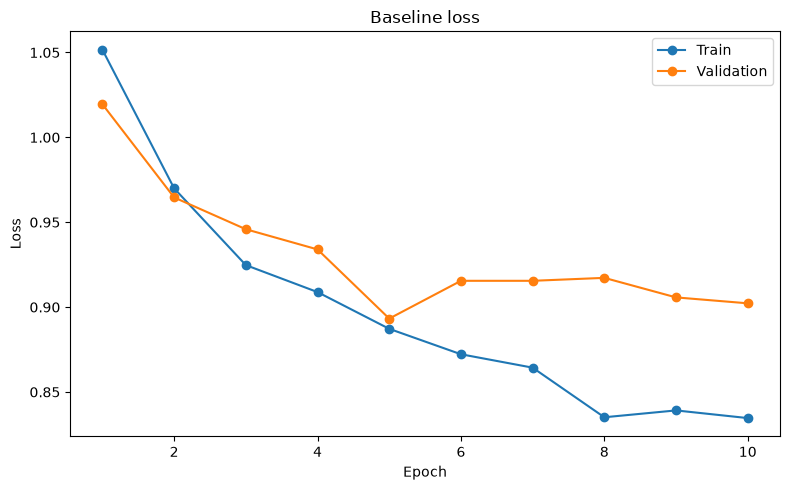

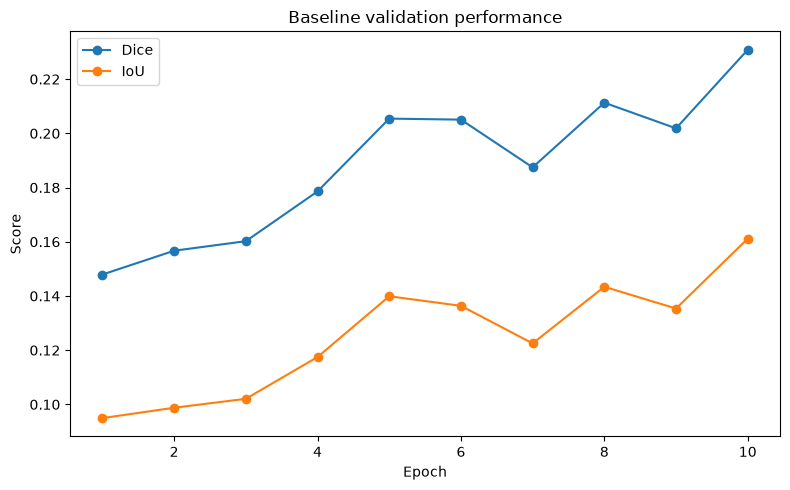

In [11]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Baseline loss")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["val_dice"], marker="o", label="Dice")
ax.plot(history_df["epoch"], history_df["val_iou"], marker="o", label="IoU")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Baseline validation performance")
ax.legend()
plt.tight_layout()
plt.show()

history_df.to_csv(
    RESULTS_DIR / "efficient_baseline_history.csv",
    index=False
)


## 11. Test evaluation


In [12]:
checkpoint = torch.load(
    CHECKPOINT_DIR / "efficient_baseline_best.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

test_metrics = evaluate(model, test_loader)

print("Best validation Dice:", checkpoint["val_dice"])
print("Best validation IoU :", checkpoint["val_iou"])
print()

for key, value in test_metrics.items():
    print(f"Test {key}: {value:.4f}")

pd.DataFrame([test_metrics]).to_csv(
    RESULTS_DIR / "efficient_baseline_test_metrics.csv",
    index=False
)


Best validation Dice: 0.23084709304757284
Best validation IoU : 0.16114866987056897

Test loss: 0.8267
Test dice: 0.2070
Test iou: 0.1434
Test precision: 0.3136
Test recall: 0.5400


## 12. Qualitative predictions


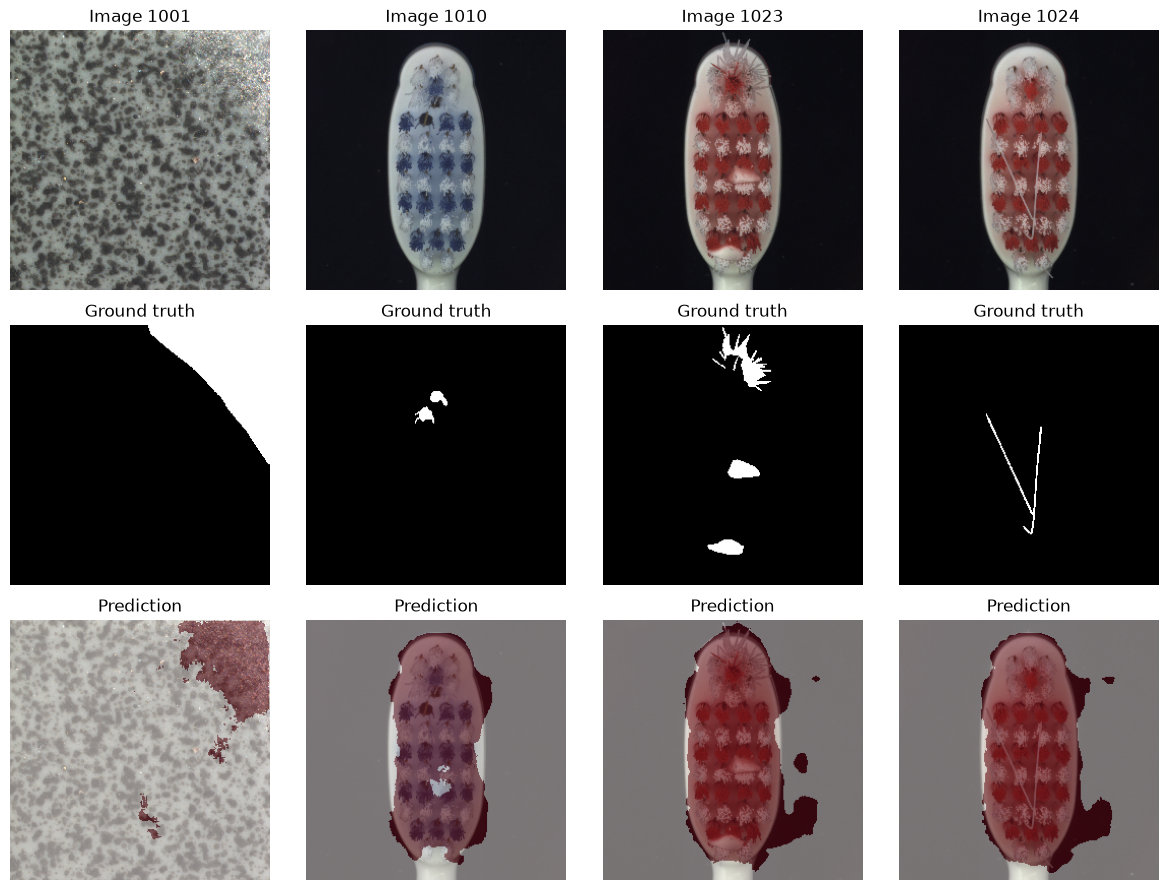

In [13]:
@torch.no_grad()
def denormalize(images):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    return (images.cpu() * std + mean).clamp(0, 1)


model.eval()

images, masks, ids = next(iter(test_loader))
logits = model(images)
preds = (torch.sigmoid(logits) >= 0.5).float()

images_vis = denormalize(images)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i in range(min(4, len(images))):
    image = images_vis[i].permute(1, 2, 0).numpy()
    true_mask = masks[i, 0].numpy()
    pred_mask = preds[i, 0].numpy()

    axes[0, i].imshow(image)
    axes[0, i].set_title(f"Image {ids[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(true_mask, cmap="gray")
    axes[1, i].set_title("Ground truth")
    axes[1, i].axis("off")

    axes[2, i].imshow(image)
    axes[2, i].imshow(pred_mask, cmap="Reds", alpha=0.45)
    axes[2, i].set_title("Prediction")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()


## 13. Save final baseline


In [14]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "test_metrics": test_metrics,
        "architecture": "EfficientSegNet CPU baseline",
        "image_size": IMAGE_SIZE
    },
    CHECKPOINT_DIR / "efficient_baseline_final.pth"
)

print("Baseline checkpoint saved.")


Baseline checkpoint saved.


## 14. Baseline interpretation

Do not judge the project by this small model alone.

Record:
- validation Dice
- validation IoU
- test Dice
- test IoU
- precision
- recall
- training time
- qualitative failures

The next stage will use this benchmark to justify a substantially stronger architecture and targeted improvements for small defects.
